# Multi-armed bandit algorithm

Madison Buitenhuis, Frankie Chen, Patrick Devine

In [ ]:
# Import necessary packages
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# Initialize a bandit machine where you can input the number of arms

class bandit_machine:
  def __init__(self, n_arms, true_vals=None, arms_std=None):
    self.n_arms = n_arms
    if true_vals is None:
      self.true_vals = np.random.normal(size=n_arms)
    else:
      self.true_vals = np.array(true_vals)

    if arms_std is None:
      self.arms_std = np.full(n_arms,1)
    else:
      self.arms_std = np.array(arms_std)

  def pull(self, arm):
    return np.random.normal(self.true_vals[arm], self.arms_std[arm])


In [ ]:
# Define the epsilon-greedy algorithm to search for a solution

def epsilon_greedy(bandit, steps, epsilon):
  estimated_vals = np.zeros(bandit.n_arms)
  num_pulls = np.zeros(bandit.n_arms)
  rewards = {}

  #define y values for later plotting
  y_vals = []

  # initiate rewards dict
  for i in range(bandit.n_arms):
    rewards[i] = [0]

  print("Game is starting ...")
  for i in range(steps):
    # Implement the epsilon method
    if np.random.random() < epsilon:
      arm = np.random.choice(bandit.n_arms)

    else:
      arm = np.argmax(estimated_vals)

    reward = bandit.pull(arm)
    num_pulls[arm] += 1
    rewards[arm] = np.append(rewards[arm], reward)
    y_vals.append(reward)

    #print("Epsilon Val:", epsilon, "Play_time_step",i+1, ": choose arm", arm, ", receive_reward", reward)
    estimated_vals[arm] += (reward - estimated_vals[arm]) / num_pulls[arm]

  total = 0
  for arm in range(bandit.n_arms):
    print("arm {}".format(arm), rewards[arm], np.sum(rewards[arm]))
    total += np.sum(rewards[arm])
  print("Total Rewards:", total)
  return y_vals



In [ ]:
# define the number of plays
N = 2000

# define an array containing the possible number of arms
n_vals = [5, 10, 20]

# Define epsilon values to evaluate (note that epislon = 0 is the regular greedy algorithm)
epsilon = [0.1]

# define an array to keep plot values
n_y = []
for n in n_vals:
  # Initialise our bandit machine
  print("running bandit machine with {} arms".format(n))
  bandit = bandit_machine(n)
  for e in epsilon:
    results = epsilon_greedy(bandit, N, e)

    #Calculate the average reward at each step for our y-vals
    for i in range(1, len(results)):
      results[i] = ((results[i-1] * i) + results[i])/(i+1)


    n_y.append(results)


running bandit machine with 5 arms
Game is starting ...
arm 0 [0.         1.06984002 1.64226506 ... 2.10054864 0.26346236 1.56654537] 1775.8515732027283
arm 1 [ 0.         -3.07948504 -3.42497767 -2.23071378 -1.8488635  -1.8374392
 -2.60850165 -1.83930367 -1.95976088 -1.11544215 -0.83496264 -2.33647718
 -2.62435585 -2.18399929 -3.11066357 -2.98102324 -1.69619656 -1.55876338
 -2.39798433 -0.8606324  -1.19492408 -2.44714269 -2.00417917 -2.86130703
 -2.59472039 -2.44582868 -3.77400622 -1.42843149 -3.31740039 -0.492843
 -2.99886396 -1.88193773 -1.52168076 -2.02997456 -2.48425396] -74.00704009983926
arm 2 [ 0.          1.01396671  0.53845081  1.6915576   1.67733441  0.70477392
 -0.82705947  2.16063584  2.1225617   2.20462397  1.17034444 -1.27773803
  0.10768678  0.00663382  0.89408949  1.06264898  0.12046691  1.72758538
  1.02442476  2.59821947  1.40385116 -0.0840517   0.22036606  0.29723358
  0.99540385  1.96701542  0.77430688  0.4786125   1.48062222  0.92500921
  1.27737684 -0.05119362  0

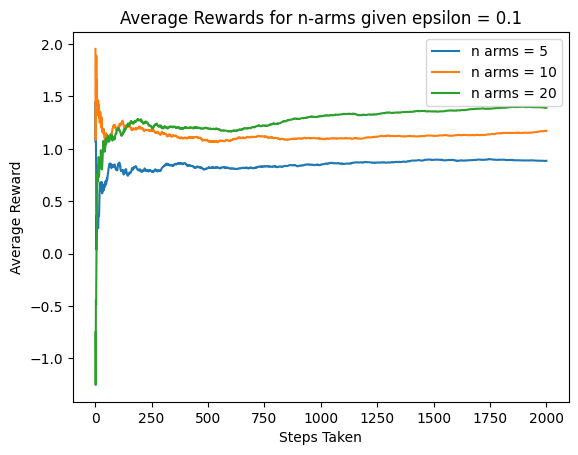

In [ ]:
# Create a plot showing the different solutions for different values of arms

x_vals = np.arange(1,N + 1)

i = 0
for n in n_vals:
  iter = "n arms = {}".format(n)
  plt.plot(x_vals, n_y[i], label = iter)
  i += 1

plt.title('Average Rewards for n-arms given epsilon = {}'.format(epsilon[0]))
plt.xlabel('Steps Taken')
plt.ylabel('Average Reward')
plt.legend()
plt.show()
